In [1]:
import os
import time
import copy
from random import shuffle

import cv2
from PIL import Image
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import tqdm.notebook as tqdm

import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import albumentations as albu


def get_transforms():
    max_pixel_value = 1.0
    mean = [0.5]
    std = [0.5]

    train_ops = []
    # if 'hflip' in opt.augs:
    train_ops.append(albu.HorizontalFlip(p=0.5))
    # if 'vflip' in opt.augs:
    train_ops.append(albu.VerticalFlip(p=0.1))
    # if 'shift_scale_rotate' in opt.augs:
    train_ops.append(albu.ShiftScaleRotate(scale_limit=0.1, rotate_limit=10, shift_limit=0.07, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0))

    data_transforms = {
        'train': albu.Compose(
            [
                *train_ops,
                albu.Resize(256, 256, cv2.INTER_LINEAR),
                albu.ToFloat(),
                albu.Normalize(mean, std, max_pixel_value=max_pixel_value),
            ]
        ),
        'val': albu.Compose(
            [
                albu.Resize(256, 256, cv2.INTER_LINEAR),
                albu.ToFloat(),
                albu.Normalize(mean, std, max_pixel_value=max_pixel_value),
            ]
        ),
    }
    return data_transforms


data_transforms = get_transforms()

In [3]:
from src.datasets.tuh_dataset import FibDataset

root_dir = "/media/NAS06/gavinyue/disentanglement/scripts_segmentation/result_exp/fid/fibrosis/fid_dataset"
split_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/data/fibrosis_splits"
split = 'val'
transforms = data_transforms['val']
scan_params = {
    'load_masks': True,
    'norm_scheme': {'kind': 'ct', 'rescale': True},
    'slicing_direction': 'axial',
    'classes': ['empty', 'fibrosis'],
    'sampling_class': ['fibrosis'],
    'default_label': ['fibrosis'],
}
val_data = FibDataset(root_dir, split, split_dir=split_dir, transforms=transforms, **scan_params)
print(len(val_data))

print(val_data[0]["image"].shape)
print(list(val_data[0].keys()))
print(val_data[0]['label'])

4007
torch.Size([1, 256, 256])
['image', 'mask', 'label', 'scan_name', 'slice_index']
tensor([1])


In [4]:
rng = torch.Generator()
rng.manual_seed(42)
test_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=1,
    shuffle=True,
    pin_memory=True,
    num_workers=0,
    generator=rng,
)

In [5]:
from src.models.classifier import ClassificationModel
from easydict import EasyDict as edict

model_config = {
    "kind": "efficientnet_v2_s",
    "n_classes": 1,
    "pretrained": True,
    "in_channels": 1,
    "loss": "bce",
    "lr": 0.0003,
    "b1": 0.9,
    "b2": 0.999,
    "weight_decay": 0.0001,
}
model_config = edict(model_config)
model = ClassificationModel(opt=model_config, img_size=[256, 256])

# Load the state dictionary
state_dict_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/tools/training_logs/classification/fibrosis/efficientnet_v2_s-August-27-2024_07+25PM-1af55fd-fibrosis+covid/checkpoints/checkpoint_970.pth'
state_dict = torch.load(state_dict_path)
model.load_state_dict(state_dict['model'])
model.eval()

/home/gavinyue/miniconda3/envs/COIN/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gavinyue/miniconda3/envs/COIN/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ClassificationModel(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchN

In [6]:
from torchmetrics import F1Score, MetricCollection, Precision, Recall

device = torch.device("cuda")

task = 'binary'
metric_list = [
    Precision(num_classes=1, task=task, average='macro'),
    Recall(num_classes=1, task=task, average='macro'),
    F1Score(num_classes=1, task=task, average='macro'),
]
train_metrics = MetricCollection(metric_list).to(device)

In [10]:
import torch.nn.functional as F

train_metrics.reset()
with torch.no_grad():
    for idx, batch in enumerate(test_loader):
        print(f"name: {batch['scan_name']}")
        batch = {k: batch[k].to(device) for k in {'image', 'label'}}
        _, pred = model(batch).values()
        prob = F.sigmoid(pred)

        # print(f"label: {batch['label'].item()}, prob: {round(prob.item(),2)}")
        # if batch['label'].item() == round(prob.item(),2):
        #     print(f"Correct prediction")
        train_metrics.update(prob, batch['label'])
        if idx >= 10:
            metrics = train_metrics.compute()
            print(metrics)
            break

name: ['origcov7091']
name: ['orig12503']
name: ['orig07197']
name: ['origcov8702']
name: ['origcov4040']
name: ['origcov7084']
name: ['origcov9596']
name: ['origcov3851']
name: ['origcov2502']
name: ['orig03206']
name: ['orig08005']
{'BinaryPrecision': tensor(1., device='cuda:0'), 'BinaryRecall': tensor(1., device='cuda:0'), 'BinaryF1Score': tensor(1., device='cuda:0')}


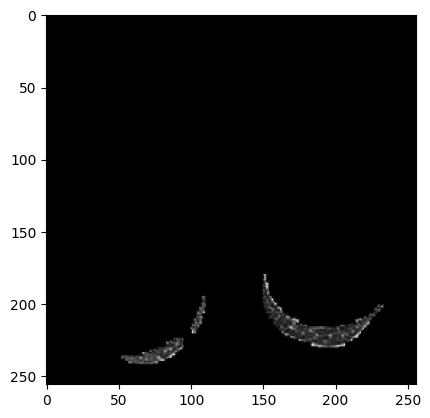

In [10]:
# {'BinaryPrecision': tensor(0.9286, device='cuda:0'), 'BinaryRecall': tensor(0.8298, device='cuda:0'), 'BinaryF1Score': tensor(0.8764, device='cuda:0')}

batch['image'].shape
plt.imshow(batch['image'].squeeze().cpu().numpy(), cmap='gray')

I have taken correct propositions of data from each classes while staging my data to avoid overfitted results. Medical Image Datasets will always be like this, we don't have enough data on victim rather we have so many healthy ones. That is what we called is a "Skewed Dataset", obviously we developed methods to approach those problems (like K-Fold Cross Validation) that will explain that in my next notebook.